### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab, jalankan sel di bawah ini dulu untuk memastikan semua paket yang dipakai sudah tersedia. Kalau saya menjalankannya di Jupyter lokal, sel ini tidak mengubah apa-apa karena semua paketnya sudah terpasang di environment.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Semua paket di bawah SUDAH tersedia di environment,
# sel ini hanya memastikan import-nya tidak error.
try:
    import sklearn
    import pandas
    import numpy
    import matplotlib
    print("Paket siap.")
except ImportError as e:
    print("Paket belum lengkap:", e)

Paket siap.


# Praktikum Machine Learning: Bab 10
## Clustering

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 10 ini mengerjakan **Latihan Praktikum Modul Bab 10 bagian 10.12**, memakai **data sintetis** pelanggan (sebagai pengganti dataset Mall Customer Segmentation dari Kaggle, sesuai izin modul) dari `sklearn.datasets.make_blobs`. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

* **Clustering itu unsupervised learning:** model mencari kelompok-kelompok sendiri dari pola datanya, tanpa diberi label target seperti pada klasifikasi.
* **K-Means:** pilih k titik centroid, tiap data ditempelkan ke centroid terdekat, centroid dihitung ulang dari rata-rata anggotanya, lalu diulang sampai tidak berubah lagi.
* **Elbow method:** plot nilai inertia (total kuadrat jarak tiap titik ke centroid clusternya) untuk berbagai nilai k. k optimal ada di "siku" grafik, yaitu titik tempat penurunan inertia mulai melandai.
* **Silhouette score:** mengukur seberapa cocok tiap titik dengan clusternya sendiri dibanding cluster tetangga terdekat. Nilainya dari -1 sampai 1, makin dekat ke 1 berarti pemisahan clusternya makin bagus.
* **Agglomerative clustering** menggabungkan titik atau cluster yang paling mirip secara bertahap dari bawah ke atas (hierarchical). **DBSCAN** mengelompokkan titik-titik yang padat bertetangga dan menandai titik yang sepi sebagai noise, sehingga cocok untuk cluster yang bentuknya tidak beraturan.

## 10.12 Latihan Praktikum (Modul Bab 10)

Di bab ini saya mengerjakan dua Latihan Praktikum dari modul bagian 10.12: pertama menentukan jumlah cluster yang optimal, lalu membandingkan tiga algoritma clustering pada dataset yang sama.

### Praktikum 1 - Menentukan k Optimal

**Tujuan:** menentukan jumlah cluster optimal menggunakan Elbow Method dan Silhouette Score.

**Instruksi (modul):** menggunakan dataset pelanggan (modul membolehkan data sintetis), buat plot Elbow Method dan Silhouette Score untuk k=2 hingga k=10, kemudian tentukan k optimal beserta justifikasinya.

Saya memakai data sintetis pelanggan dari `make_blobs` dengan 5 pusat cluster dan 1000 baris. Dua fiturnya saya beri nama "Annual Income" dan "Spending Score" supaya terasa seperti data segmentasi pelanggan mal.

Bentuk data: (1000, 2)
   Annual Income  Spending Score
0       5.096116        2.705873
1       2.950865        1.039790
2      -5.953589      -10.298361
3       5.311627        3.270107
4       1.252522        4.679759


k=2: inertia=29580.7, silhouette=0.578


k=3: inertia=8198.6, silhouette=0.679


k=4: inertia=3961.2, silhouette=0.687


k=5: inertia=2633.8, silhouette=0.629


k=6: inertia=2410.3, silhouette=0.556


k=7: inertia=2202.1, silhouette=0.455


k=8: inertia=2002.3, silhouette=0.408


k=9: inertia=1833.0, silhouette=0.347


k=10: inertia=1679.4, silhouette=0.328


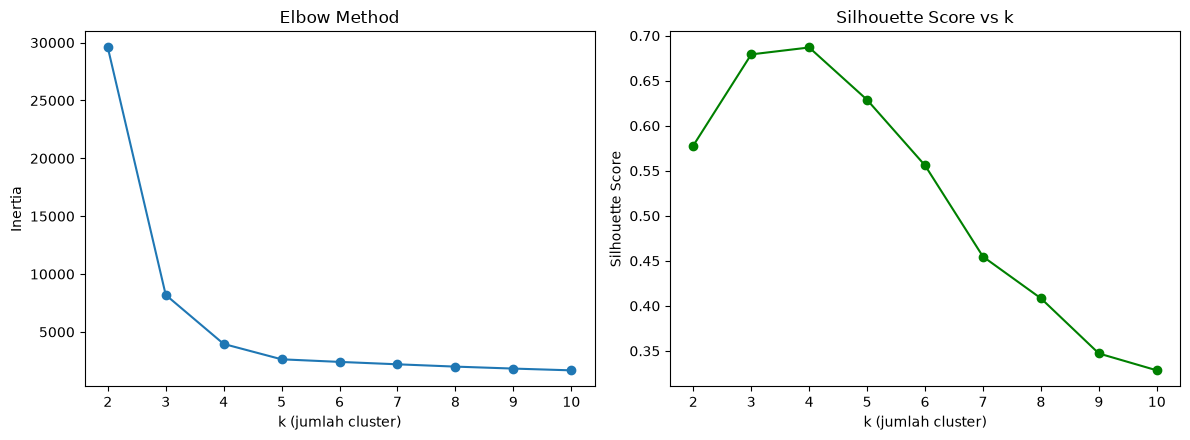

k dengan silhouette score tertinggi: 4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data sintetis pelanggan: 1000 baris, 5 pusat cluster, 2 fitur.
X, _ = make_blobs(n_samples=1000, centers=5, n_features=2,
                  cluster_std=1.2, random_state=42)
df = pd.DataFrame(X, columns=["Annual Income", "Spending Score"])
print("Bentuk data:", df.shape)
print(df.head())

# Elbow method + silhouette score untuk k = 2 sampai 10.
ks = list(range(2, 11))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouettes[-1]:.3f}")

# Satu figure, dua subplot berdampingan.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_xlabel("k (jumlah cluster)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(ks)
axes[1].plot(ks, silhouettes, marker="o", color="green")
axes[1].set_xlabel("k (jumlah cluster)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xticks(ks)
plt.tight_layout()
plt.show()

k_optimal = ks[int(np.argmax(silhouettes))]
print("k dengan silhouette score tertinggi:", k_optimal)

**Penjelasan outputnya:**

Datanya terbaca 1000 baris dengan 2 kolom, "Annual Income" dan "Spending Score", sesuai yang saya buat dari `make_blobs`. Dari hasil loop k=2 sampai k=10, inertia turun sangat tajam di awal: 29580.7 (k=2), 8198.6 (k=3), 3961.2 (k=4), 2633.8 (k=5), lalu melandai setelahnya (2410.3 di k=6, 2202.1 di k=7, dan seterusnya). Di grafik elbow, "siku" nya terlihat jelas di k=5, karena penurunan dari k=4 ke k=5 masih besar (sekitar 1327) sedangkan dari k=5 ke k=6 tinggal sekitar 223.

Silhouette score tertingginya ada di k=4 (0.687), disusul k=3 (0.679) dan k=5 (0.629). Setelah k=5 skornya anjlok terus sampai 0.328 di k=10, yang artinya memaksakan terlalu banyak cluster justru merusak pemisahannya.

**Justifikasi k optimal: saya pilih k=5.** Elbow method menunjuk k=5 dengan tegas, silhouette di k=5 masih bagus (0.629, tertinggi ketiga dan jauh di atas k=6 ke atas), dan angka ini juga cocok dengan 5 pusat cluster yang saya pakai saat membuat datanya. Jadi k=5 adalah titik temu kedua metode.

### Praktikum 2 - Segmentasi dengan Tiga Algoritma

**Tujuan:** membandingkan hasil clustering ketiga algoritma pada dataset yang sama.

**Instruksi (modul, Praktikum 10.7):** kode di modul hanya berupa komentar, jadi saya implementasikan langsung seperti ini:

```python
# Terapkan K-Means, Hierarchical (Agglomerative),
# dan DBSCAN pada dataset yang sama.
# Bandingkan jumlah cluster yang dihasilkan,
# Silhouette Score, dan visualisasikan ketiganya
# dalam satu figure berdampingan (subplot). Tuliskan analis
# is mengenai algoritma mana
# yang menghasilkan segmentasi paling masuk akal secara bis
# nis untuk kasus Anda.
```

Saya memakai dataset X yang sama seperti Praktikum 1. Untuk DBSCAN saya pakai eps=0.9 dan min_samples=10, dan silhouette score-nya saya hitung di luar titik noise (label -1).

Algoritma     Cluster  Noise   Silhouette
K-Means       5        0       0.629


Agglomerative 5        0       0.623
DBSCAN        4        31      0.699


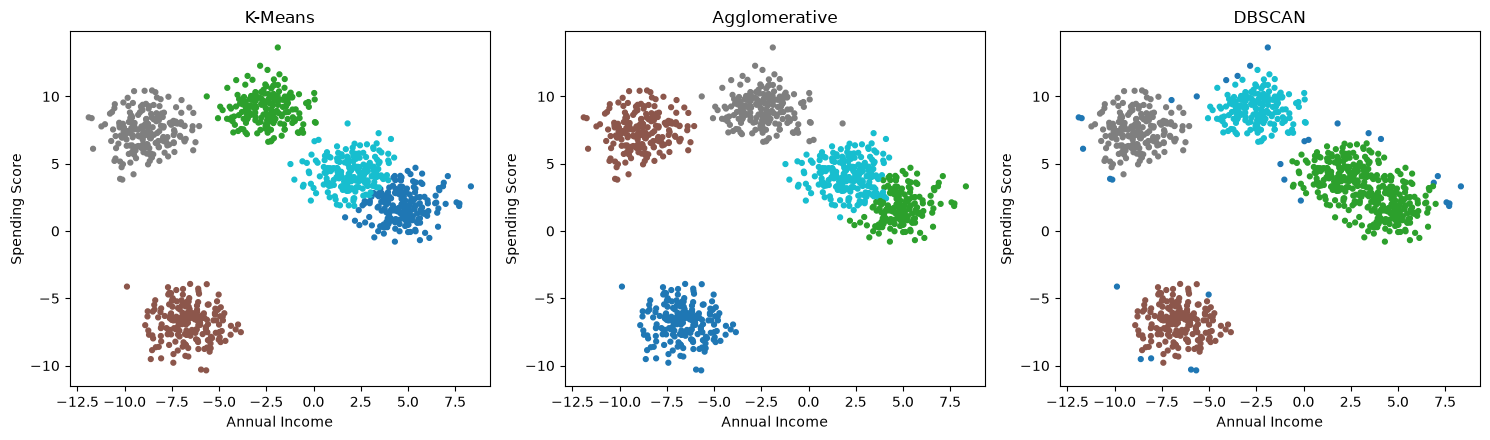

In [3]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# Terapkan ketiga algoritma pada dataset yang sama.
hasil_label = {
    "K-Means": KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X),
    "Agglomerative": AgglomerativeClustering(n_clusters=5).fit_predict(X),
    "DBSCAN": DBSCAN(eps=0.9, min_samples=10).fit_predict(X),
}

# Bandingkan jumlah cluster dan silhouette score tiap algoritma.
print(f"{'Algoritma':<14}{'Cluster':<9}{'Noise':<8}Silhouette")
for nama, labels in hasil_label.items():
    tanpa_noise = labels[labels != -1]
    n_cluster = len(set(tanpa_noise))
    n_noise = int((labels == -1).sum())
    sil = silhouette_score(X[labels != -1], tanpa_noise) if n_cluster > 1 else float("nan")
    print(f"{nama:<14}{n_cluster:<9}{n_noise:<8}{sil:.3f}")

# Visualisasikan ketiganya dalam satu figure berdampingan.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nama, labels) in zip(axes, hasil_label.items()):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=12)
    ax.set_xlabel("Annual Income")
    ax.set_ylabel("Spending Score")
    ax.set_title(nama)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

Tabel perbandingannya menunjukkan K-Means dan Agglomerative sama-sama menghasilkan tepat 5 cluster tanpa noise, dengan silhouette score yang hampir identik: 0.629 untuk K-Means dan 0.623 untuk Agglomerative. DBSCAN menemukan 4 cluster dengan 31 titik ditandai sebagai noise, dan silhouette score di luar noise-nya 0.699, paling tinggi di antara ketiganya.

Dari scatter plot berdampingan terlihat K-Means dan Agglomerative memetakan kelima gugus pelanggan dengan rapi dan konsisten. DBSCAN menggabungkan dua gugus yang berdekatan menjadi satu cluster dan membuang 31 titik sebagai noise, sehingga segmentasinya lebih kasar.

**Analisis:** untuk kasus segmentasi pelanggan ini, **K-Means paling masuk akal secara bisnis**. Alasannya: setiap pelanggan harus masuk ke satu segmen agar bisa ditindaklanjuti tim marketing, dan K-Means menempatkan semua 1000 pelanggan ke 5 segmen yang jelas tanpa ada yang dibuang sebagai noise. Agglomerative hasilnya nyaris sama bagusnya, jadi bisa jadi alternatif. DBSCAN memang punya silhouette tertinggi, tapi ia mengorbankan satu segmen dan membuang 31 pelanggan sebagai noise, sehingga kurang cocok dipakai untuk segmentasi pelanggan yang butuh seluruh data terpetakan.

## Kesimpulan Bab 10

* Elbow method dan silhouette score bisa dipakai bersama untuk menentukan jumlah cluster: di data ini keduanya mengarah ke k=5, dengan siku inertia yang jelas dan silhouette 0.629.
* K-Means dan Agglomerative clustering menghasilkan segmentasi yang setara bagusnya pada data pelanggan ini (silhouette 0.629 vs 0.623, sama-sama 5 cluster tanpa noise).
* DBSCAN menemukan 4 cluster dengan silhouette tertinggi (0.699) tetapi menggabungkan dua segmen dan menandai 31 titik sebagai noise, sehingga kurang pas untuk kebutuhan segmentasi pelanggan.
* Untuk kasus bisnis seperti segmentasi pelanggan mal, algoritma yang menempatkan seluruh data ke segmen yang jelas (K-Means) lebih masuk akal dibanding yang membuang data sebagai noise.